# 作业 2


In [7]:
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def set_plot_style():
    """A clean, paper-like matplotlib style (Nature-ish)."""

    # High-contrast palette (Tableau / Matplotlib tab10-like)
    palette = [
        "#1F77B4",  # blue
        "#FF7F0E",  # orange
        "#2CA02C",  # green
        "#D62728",  # red
        "#9467BD",  # purple
        "#8C564B",  # brown
        "#E377C2",  # pink
        "#7F7F7F",  # gray
        "#BCBD22",  # olive
        "#17BECF",  # cyan
    ]

    plt.rcParams.update(
        {
            # Typography
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "DejaVu Sans"],
            "svg.fonttype": "none",  # keep text editable in SVG/PDF
            "font.size": 13,
            # Axes
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.linewidth": 1.5,
            "axes.grid": False,  # remove grid globally
            # Color
            "axes.prop_cycle": plt.cycler(color=palette),
            # Ticks
            "xtick.direction": "out",
            "ytick.direction": "out",
            "xtick.major.size": 4,
            "ytick.major.size": 4,
            # Lines
            "lines.linewidth": 2.0,
            "lines.markersize": 5,
            # Figure
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
        }
    )


set_plot_style()


SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
try:
    torch.set_num_threads(1)
except Exception:
    pass

print(f"PyTorch version: {torch.__version__}")
print(f"Default device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.5.1
Default device: cuda


##  2 多层感知机
## 2.1 理论计算题 第 1 题

单隐藏层多层感知机为

$$
\mathbf{h}=W_1\mathbf{x}+\mathbf{b}_1,
\qquad
\mathbf{o}=W_2\mathbf{h}+\mathbf{b}_2.
$$

因为隐藏层没有非线性激活函数，所以将第一式代入第二式可得

$$
\begin{aligned}
\mathbf{o}
&= W_2(W_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2 \\
&= (W_2W_1)\mathbf{x} + W_2\mathbf{b}_1+\mathbf{b}_2.
\end{aligned}
$$

令

$$
W' = W_2W_1,\qquad \mathbf{b}'=W_2\mathbf{b}_1+\mathbf{b}_2,
$$

则网络输出可写为

$$
\mathbf{o}=W'\mathbf{x}+\mathbf{b}'.
$$

这正是一个单层线性神经网络的形式。因此，如果隐藏层没有非线性激活函数，多层线性变换的复合仍然只是一个线性变换；增加线性隐藏层不会提升模型表达非线性函数的能力。

## 2.1 理论计算题 第 2 题

### Sigmoid 函数

Sigmoid 函数定义为

$$
\sigma(x)=\frac{1}{1+e^{-x}}.
$$

对其求导：

$$
\begin{aligned}
\sigma'(x)
&= \frac{e^{-x}}{(1+e^{-x})^2} \\
&= \frac{1}{1+e^{-x}}\left(1-\frac{1}{1+e^{-x}}\right) \\
&= \sigma(x)(1-\sigma(x)).
\end{aligned}
$$

因此，Sigmoid 导数与函数自身的关系为

$$
\boxed{\sigma'(x)=\sigma(x)(1-\sigma(x))}.
$$

### tanh 函数

双曲正切函数定义为

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}.
$$

利用恒等式

$$
\tanh(x)=\frac{e^{2x}-1}{e^{2x}+1},
$$

可得

$$
\begin{aligned}
\tanh'(x)
&= \frac{4e^{2x}}{(e^{2x}+1)^2}.
\end{aligned}
$$

另一方面，

$$
1-\tanh^2(x)
=1-\left(\frac{e^{2x}-1}{e^{2x}+1}\right)^2
=\frac{(e^{2x}+1)^2-(e^{2x}-1)^2}{(e^{2x}+1)^2}
=\frac{4e^{2x}}{(e^{2x}+1)^2}.
$$

所以

$$
\boxed{\tanh'(x)=1-\tanh^2(x)}.
$$

## 2.2 编程题

In [8]:
import gzip
import shutil
import struct
import urllib.request

FASHION_MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

FASHION_MNIST_MIRRORS = [
    "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/",
    "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/",
]


def download_file(filename, raw_dir):
    raw_dir.mkdir(parents=True, exist_ok=True)
    target = raw_dir / filename
    if target.exists() and target.stat().st_size > 0:
        return target

    last_error = None
    for base_url in FASHION_MNIST_MIRRORS:
        url = base_url + filename
        try:
            print(f"Downloading {url}")
            with urllib.request.urlopen(url, timeout=30) as response, open(target, "wb") as f:
                shutil.copyfileobj(response, f)
            if target.stat().st_size > 0:
                return target
        except Exception as exc:
            last_error = exc
            if target.exists():
                target.unlink()

    raise RuntimeError(
        f"无法下载 {filename}。请检查网络，或手动将 Fashion-MNIST gzip 文件放入 {raw_dir}。最后错误：{last_error}"
    )


def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"{path} 不是 IDX image 文件，magic={magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8).copy()
    return torch.tensor(data, dtype=torch.float32).reshape(num, rows * cols) / 255.0


def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"{path} 不是 IDX label 文件，magic={magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8).copy()
    return torch.tensor(data, dtype=torch.long)


def load_fashion_mnist(data_dir="data/fashion-mnist", download=True):
    raw_dir = Path(data_dir) / "raw"
    paths = {}
    for key, filename in FASHION_MNIST_FILES.items():
        path = raw_dir / filename
        if not path.exists():
            if not download:
                raise FileNotFoundError(f"缺少 {path}")
            path = download_file(filename, raw_dir)
        paths[key] = path

    X_train = read_idx_images(paths["train_images"])
    y_train = read_idx_labels(paths["train_labels"])
    X_test = read_idx_images(paths["test_images"])
    y_test = read_idx_labels(paths["test_labels"])
    return X_train, y_train, X_test, y_test


def data_iter(batch_size, X, y, shuffle=True):
    n = X.shape[0]
    indices = torch.randperm(n) if shuffle else torch.arange(n)
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def init_mlp_params(num_inputs, num_hiddens, num_outputs, device):
    W1 = torch.normal(0, 0.01, (num_inputs, num_hiddens), device=device, requires_grad=True)
    b1 = torch.zeros(num_hiddens, device=device, requires_grad=True)
    W2 = torch.normal(0, 0.01, (num_hiddens, num_outputs), device=device, requires_grad=True)
    b2 = torch.zeros(num_outputs, device=device, requires_grad=True)
    return [W1, b1, W2, b2]


def relu(X):
    return torch.clamp(X, min=0.0)


def mlp_forward(X, params):
    W1, b1, W2, b2 = params
    H = relu(X @ W1 + b1)
    return H @ W2 + b2


def softmax_cross_entropy(logits, y):
    # logsumexp 形式等价于 Softmax + Cross Entropy，并避免 exp 溢出。
    return (torch.logsumexp(logits, dim=1) - logits[torch.arange(y.numel(), device=y.device), y]).mean()


def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def evaluate_classification(params, X, y, batch_size, device):
    total_loss, total_correct, total_count = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in data_iter(batch_size, X, y, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            logits = mlp_forward(Xb, params)
            loss = softmax_cross_entropy(logits, yb)
            total_loss += loss.item() * yb.numel()
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += yb.numel()
    return total_loss / total_count, total_correct / total_count


def sgd(params, lr):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()


def train_fashion_mlp(X_train, y_train, X_val, y_val, *, num_epochs=5, batch_size=256, lr=0.1, num_hiddens=256, device="cpu"):
    params = init_mlp_params(X_train.shape[1], num_hiddens, 10, device)
    history = []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        for Xb, yb in data_iter(batch_size, X_train, y_train, shuffle=True):
            Xb, yb = Xb.to(device), yb.to(device)
            logits = mlp_forward(Xb, params)
            loss = softmax_cross_entropy(logits, yb)
            loss.backward()
            sgd(params, lr)

        train_loss, train_acc = evaluate_classification(params, X_train, y_train, batch_size, device)
        val_loss, val_acc = evaluate_classification(params, X_val, y_val, batch_size, device)
        history.append((epoch, train_loss, train_acc, val_loss, val_acc))
        print(
            f"epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
            f"time={time.time() - t0:.1f}s"
        )

    return params, np.array(history, dtype=float)

Fashion-MNIST shapes: torch.Size([60000, 784]) torch.Size([60000]) torch.Size([10000, 784]) torch.Size([10000])
epoch 01 | train_loss=0.6726, train_acc=0.7656 | val_loss=0.6566, val_acc=0.7702 | time=1.1s
epoch 02 | train_loss=0.5616, train_acc=0.8006 | val_loss=0.5519, val_acc=0.7988 | time=1.1s
epoch 03 | train_loss=0.5005, train_acc=0.8226 | val_loss=0.4966, val_acc=0.8186 | time=1.2s
epoch 04 | train_loss=0.4899, train_acc=0.8293 | val_loss=0.4864, val_acc=0.8304 | time=1.3s
epoch 05 | train_loss=0.4471, train_acc=0.8446 | val_loss=0.4465, val_acc=0.8414 | time=3.3s
Test loss=0.4790, test accuracy=0.8295


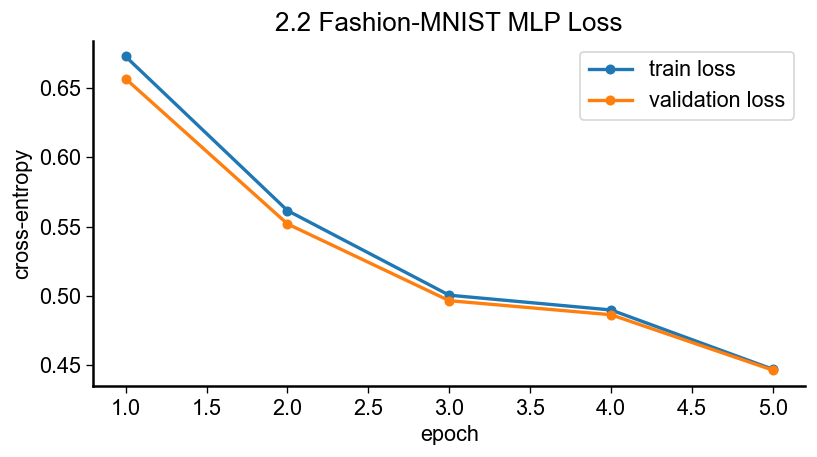

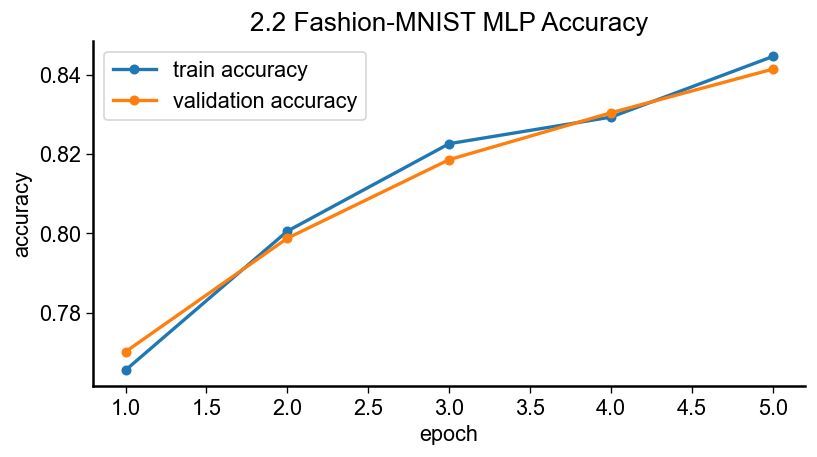

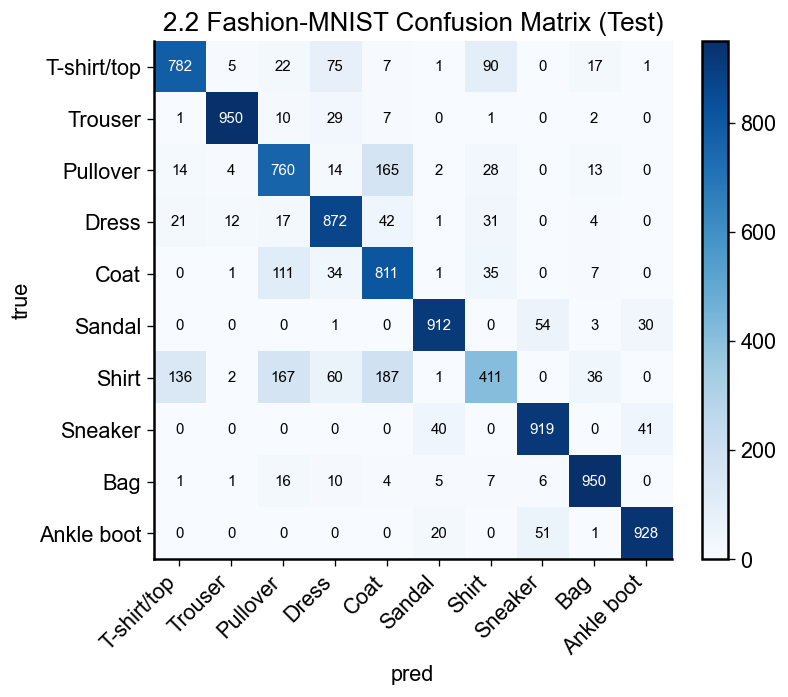

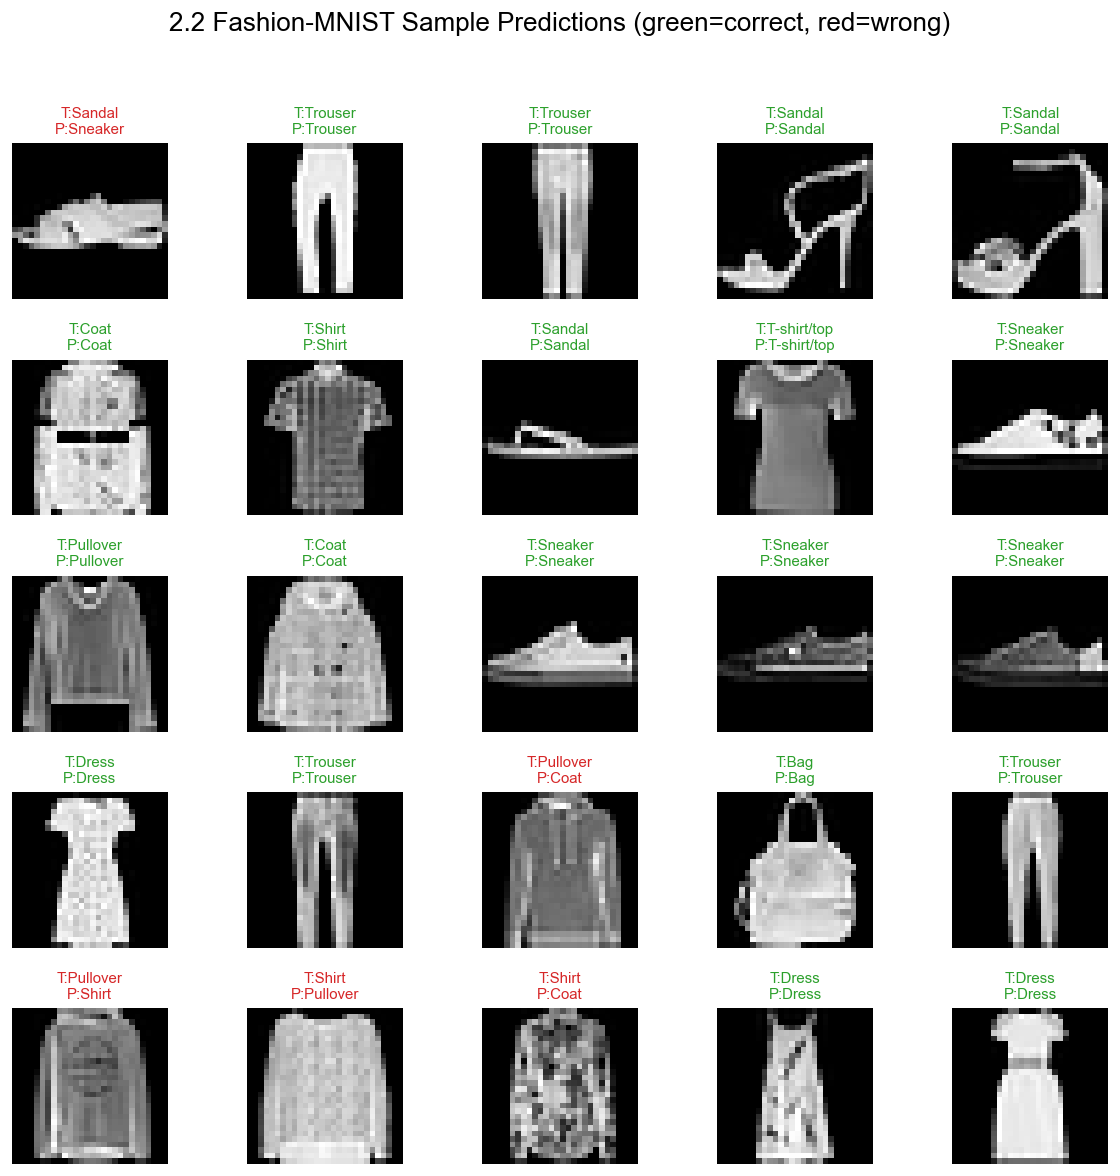

In [9]:
# Fashion-MNIST 单隐藏层 MLP 训练

RUN_FASHION_MNIST = True
TRAIN_LIMIT = None
TEST_LIMIT = None
VAL_SIZE = 5000

if RUN_FASHION_MNIST:
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X_train_all, y_train_all, X_test, y_test = load_fashion_mnist(download=True)
        print("Fashion-MNIST shapes:", X_train_all.shape, y_train_all.shape, X_test.shape, y_test.shape)

        if TRAIN_LIMIT is not None:
            X_train_all = X_train_all[:TRAIN_LIMIT]
            y_train_all = y_train_all[:TRAIN_LIMIT]
        if TEST_LIMIT is not None:
            X_test = X_test[:TEST_LIMIT]
            y_test = y_test[:TEST_LIMIT]

        X_val, y_val = X_train_all[-VAL_SIZE:], y_train_all[-VAL_SIZE:]
        X_train, y_train = X_train_all[:-VAL_SIZE], y_train_all[:-VAL_SIZE]

        params_22, history_22 = train_fashion_mlp(
            X_train,
            y_train,
            X_val,
            y_val,
            num_epochs=5,
            batch_size=256,
            lr=0.1,
            num_hiddens=256,
            device=device,
        )

        test_loss, test_acc = evaluate_classification(params_22, X_test, y_test, batch_size=256, device=device)
        print(f"Test loss={test_loss:.4f}, test accuracy={test_acc:.4f}")

        plt.figure(figsize=(7, 4))
        plt.plot(history_22[:, 0], history_22[:, 1], marker="o", label="train loss")
        plt.plot(history_22[:, 0], history_22[:, 3], marker="o", label="validation loss")
        plt.xlabel("epoch")
        plt.ylabel("cross-entropy")
        plt.title("2.2 Fashion-MNIST MLP Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(history_22[:, 0], history_22[:, 2], marker="o", label="train accuracy")
        plt.plot(history_22[:, 0], history_22[:, 4], marker="o", label="validation accuracy")
        plt.xlabel("epoch")
        plt.ylabel("accuracy")
        plt.title("2.2 Fashion-MNIST MLP Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # --- extra visualizations (cleaner & more informative) ---
        FASHION_CLASSES = [
            "T-shirt/top",
            "Trouser",
            "Pullover",
            "Dress",
            "Coat",
            "Sandal",
            "Shirt",
            "Sneaker",
            "Bag",
            "Ankle boot",
        ]

        with torch.no_grad():
            logits_test = mlp_forward(X_test.to(device), params_22).cpu()
            y_pred = logits_test.argmax(dim=1)

        # 1) Confusion matrix
        num_classes = 10
        idx = (y_test * num_classes + y_pred).to(torch.int64)
        cm = torch.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

        plt.figure(figsize=(7.5, 6))
        im = plt.imshow(cm.numpy(), cmap="Blues")
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.title("2.2 Fashion-MNIST Confusion Matrix (Test)")
        plt.xlabel("pred")
        plt.ylabel("true")
        plt.xticks(range(num_classes), FASHION_CLASSES, rotation=45, ha="right")
        plt.yticks(range(num_classes), FASHION_CLASSES)
        for i in range(num_classes):
            for j in range(num_classes):
                v = int(cm[i, j].item())
                plt.text(j, i, str(v), ha="center", va="center", fontsize=9, color="black" if v < cm.max() * 0.6 else "white")
        plt.tight_layout()
        plt.show()

        # 2) Sample predictions grid
        torch.manual_seed(SEED)
        n_show = 25
        show_idx = torch.randperm(X_test.shape[0])[:n_show]
        imgs = X_test[show_idx].reshape(-1, 28, 28)
        yt = y_test[show_idx]
        yp = y_pred[show_idx]

        plt.figure(figsize=(10, 10))
        for k in range(n_show):
            ax = plt.subplot(5, 5, k + 1)
            ax.imshow(imgs[k].numpy(), cmap="gray")
            ax.axis("off")
            ok = int(yt[k].item()) == int(yp[k].item())
            ax.set_title(
                f"T:{FASHION_CLASSES[int(yt[k].item())]}\nP:{FASHION_CLASSES[int(yp[k].item())]}",
                fontsize=9,
                color=("#2ca02c" if ok else "#d62728"),
            )
        plt.suptitle("2.2 Fashion-MNIST Sample Predictions (green=correct, red=wrong)")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as exc:
        print("Fashion-MNIST 数据暂不可用，未执行 2.2 训练。")
        print("请在可联网环境中重新运行，或手动下载四个 gzip 文件到 data/fashion-mnist/raw/。")
        print("错误信息：", repr(exc))
else:
    print("RUN_FASHION_MNIST=False，已跳过 2.2 训练。")

## 3 模型选择，权重衰减和丢弃法
## 3.1 理论计算题 第 1 题

**训练误差**是模型在训练集上的平均损失或错误率，通常可写为经验风险

$$
\hat{R}(f)=\frac{1}{n}\sum_{i=1}^n \ell(f(x_i),y_i).
$$

**泛化误差**是模型在未见样本上的期望误差，反映模型在真实数据分布上的预测能力：

$$
R(f)=\mathbb{E}_{(x,y)\sim P}\left[\ell(f(x),y)\right].
$$

当模型的训练误差极低，但泛化误差很高时，模型处于**过拟合**状态。此时模型不仅学习了训练数据中的有效规律，也记住了训练样本的噪声、偶然性或局部细节。

缓解过拟合可以从控制模型复杂度入手：

1. 减小模型容量，例如减少隐藏层宽度、减少层数或降低多项式阶数。
2. 使用正则化，例如 $L_2$ 权重衰减、$L_1$ 正则化、Dropout。
3. 使用早停法，根据验证集误差决定停止训练的时机。
4. 增加训练数据或使用数据增强。
5. 用验证集或交叉验证选择超参数，避免只根据训练误差调参。

相反，如果训练误差和泛化误差都很高，通常说明模型欠拟合，需要增加模型容量、训练更久或改进特征表达。

## 3.1 理论计算题 第 2 题

K 折交叉验证的算法步骤如下：

1. 将原始训练数据随机打乱，并均分为 $K$ 个互不重叠的子集：

   $$
   D_1,D_2,\ldots,D_K.
   $$

2. 对第 $k$ 次实验，取 $D_k$ 作为验证集，取其余 $K-1$ 份作为训练集：

   $$
   D_{\text{train}}^{(k)}=D\setminus D_k,
   \qquad
   D_{\text{val}}^{(k)}=D_k.
   $$

3. 在 $D_{\text{train}}^{(k)}$ 上训练模型，在 $D_{\text{val}}^{(k)}$ 上计算验证误差 $E_k$。

4. 对 $k=1,2,\ldots,K$ 重复上述过程，使每个子集都恰好作为一次验证集。

5. 用 $K$ 次验证误差的均值作为模型或超参数组合的性能估计：

   $$
   \bar{E}=\frac{1}{K}\sum_{k=1}^{K}E_k.
   $$

6. 对不同模型复杂度或超参数组合分别执行 K 折交叉验证，选择平均验证误差最小的方案。最终通常用选定超参数在完整训练集上重新训练模型，再在测试集上报告最终性能。

## 3.2 编程题

在从零实现的 MLP 上加入两种正则化机制：

- **权重衰减**：在自定义 SGD 中对权重参数执行

  $$
  W \leftarrow (1-\eta\lambda)W
  $$

  然后再执行梯度更新。偏置不做权重衰减。

- **Dropout**：从零实现 `dropout_layer(X, dropout)`，训练时随机屏蔽神经元并按 $1/(1-p)$ 缩放，测试或验证时关闭 Dropout。

对比实验采用“小样本 + 大隐藏层”的回归任务。训练集只有 30 个带噪声样本，验证集使用无噪声目标函数。模型容量相对数据量过大，因此无正则化模型更容易过拟合。

Final MSE comparison:
no regularization  | train MSE=0.2881 | validation MSE=0.6455
weight decay       | train MSE=0.5032 | validation MSE=0.5096
dropout            | train MSE=0.3355 | validation MSE=0.5725


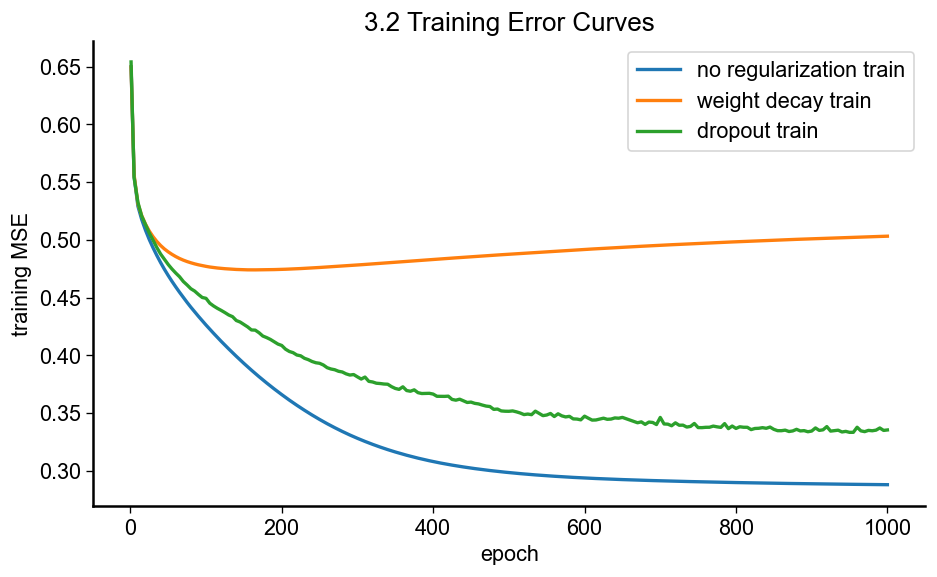

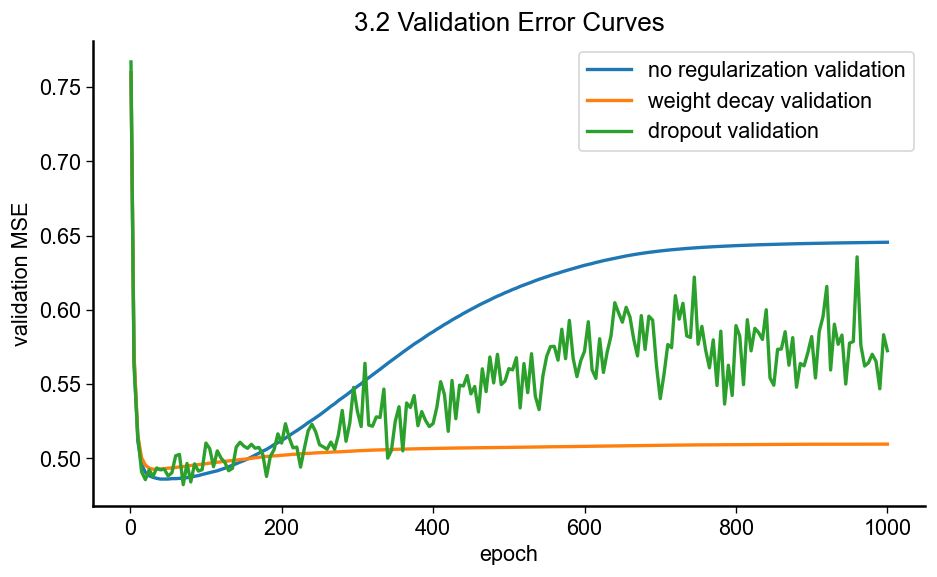

Validation MSE 最低的设置：weight decay


In [10]:
# 3.2 从零实现权重衰减和 Dropout，并比较训练/验证误差曲线

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_regularization_data(seed=SEED, n_train=30, n_val=200):
    torch.manual_seed(seed)
    X_train = torch.linspace(-2.5, 2.5, n_train).reshape(-1, 1)
    X_train += 0.05 * torch.randn_like(X_train)
    X_val = torch.linspace(-3.0, 3.0, n_val).reshape(-1, 1)

    def target(x):
        return torch.sin(2.5 * x) + 0.3 * x

    y_train = target(X_train) + 0.35 * torch.randn_like(X_train)
    y_val = target(X_val)
    return X_train, y_train, X_val, y_val


def init_regression_mlp(hidden=256, scale=0.1):
    W1 = (torch.randn(1, hidden) * scale).requires_grad_()
    b1 = torch.zeros(hidden, requires_grad=True)
    W2 = (torch.randn(hidden, 1) * scale).requires_grad_()
    b2 = torch.zeros(1, requires_grad=True)
    return [W1, b1, W2, b2]


def dropout_layer(X, dropout):
    if dropout < 0 or dropout > 1:
        raise ValueError("dropout must be in [0, 1]")
    if dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)


def regression_mlp_forward(X, params, dropout=0.0, is_training=False):
    W1, b1, W2, b2 = params
    H = relu(X @ W1 + b1)
    if is_training and dropout > 0:
        H = dropout_layer(H, dropout)
    return H @ W2 + b2


def mse_loss(y_hat, y):
    return ((y_hat - y) ** 2).mean()


def sgd_with_weight_decay(params, lr, weight_decay=0.0):
    W1, b1, W2, b2 = params
    with torch.no_grad():
        if weight_decay > 0:
            W1 *= (1.0 - lr * weight_decay)
            W2 *= (1.0 - lr * weight_decay)
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()


def train_regularized_mlp(config, seed=SEED, epochs=1000, lr=0.03):
    X_train, y_train, X_val, y_val = make_regularization_data(seed)
    params = init_regression_mlp(hidden=256, scale=0.1)
    weight_decay = config.get("weight_decay", 0.0)
    dropout = config.get("dropout", 0.0)
    history = []

    for epoch in range(1, epochs + 1):
        y_hat = regression_mlp_forward(X_train, params, dropout=dropout, is_training=True)
        loss = mse_loss(y_hat, y_train)
        loss.backward()
        sgd_with_weight_decay(params, lr, weight_decay)

        if epoch == 1 or epoch % 5 == 0:
            with torch.no_grad():
                train_mse = mse_loss(regression_mlp_forward(X_train, params, is_training=False), y_train).item()
                val_mse = mse_loss(regression_mlp_forward(X_val, params, is_training=False), y_val).item()
            history.append((epoch, train_mse, val_mse))

    return np.array(history, dtype=float)

experiments_32 = {
    "no regularization": {},
    "weight decay": {"weight_decay": 0.1},
    "dropout": {"dropout": 0.5},
}

histories_32 = {}
for name, cfg in experiments_32.items():
    histories_32[name] = train_regularized_mlp(cfg)

print("Final MSE comparison:")
for name, hist in histories_32.items():
    print(f"{name:18s} | train MSE={hist[-1, 1]:.4f} | validation MSE={hist[-1, 2]:.4f}")

plt.figure(figsize=(8, 5))
for name, hist in histories_32.items():
    plt.plot(hist[:, 0], hist[:, 1], label=f"{name} train")
plt.xlabel("epoch")
plt.ylabel("training MSE")
plt.title("3.2 Training Error Curves")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for name, hist in histories_32.items():
    plt.plot(hist[:, 0], hist[:, 2], label=f"{name} validation")
plt.xlabel("epoch")
plt.ylabel("validation MSE")
plt.title("3.2 Validation Error Curves")
plt.legend()
plt.tight_layout()
plt.show()

best_name = min(histories_32, key=lambda name: histories_32[name][-1, 2])
print(f"Validation MSE 最低的设置：{best_name}")

### 3.2 结果分析

无正则化模型通常能把训练误差压得更低，但验证误差不一定最低，这说明模型在小样本噪声上发生了过拟合。权重衰减通过限制权重范数降低模型有效复杂度；Dropout 通过随机屏蔽隐藏单元减少神经元之间的复杂共适应。对比训练与验证曲线可以看到，正则化方法往往牺牲一部分训练集拟合能力，换取更稳健的验证集表现。

## 4 数值稳定性和激活函数
## 4.1 理论计算题

深层网络中，反向传播到第 $t$ 层的梯度包含多层 Jacobian 的连乘：

$$
\frac{\partial L}{\partial h^t}
=\frac{\partial L}{\partial h^d}
\prod_{i=t}^{d-1}\frac{\partial h^{i+1}}{\partial h^i}.
$$

若第 $i$ 层为

$$
h^{i+1}=\phi(W_i h^i+b_i),
$$

则对应的 Jacobian 可写为

$$
J_i=\frac{\partial h^{i+1}}{\partial h^i}
=\operatorname{diag}(\phi'(z_i))W_i,
\qquad z_i=W_i h^i+b_i.
$$

因此梯度范数满足上界

$$
\left\|\frac{\partial L}{\partial h^t}\right\|
\le
\left\|\frac{\partial L}{\partial h^d}\right\|
\prod_{i=t}^{d-1}\|J_i\|.
$$

从矩阵乘法角度看，若各层 Jacobian 的主要奇异值或谱范数平均大于 1，则连乘项会随深度指数级放大，导致**梯度爆炸**：

$$
\prod_{i=t}^{d-1}\|J_i\| \gg 1.
$$

若各层 Jacobian 的主要奇异值或谱范数平均小于 1，则连乘项会随深度指数级衰减，导致**梯度消失**：

$$
\prod_{i=t}^{d-1}\|J_i\| \approx 0.
$$

从激活函数导数角度看，Sigmoid 的导数最大只有

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))\le 0.25,
$$

并且当 $x$ 很大或很小时，Sigmoid 饱和，导数接近 0。tanh 的导数为

$$
\tanh'(x)=1-\tanh^2(x),
$$

在饱和区也接近 0。多层小于 1 的导数相乘会迅速衰减。

ReLU 的导数为

$$
\operatorname{ReLU}'(x)=
\begin{cases}
1, & x>0,\\
0, & x\le 0.
\end{cases}
$$

当神经元处于激活状态时，ReLU 的导数为 1，不会像 Sigmoid 那样引入最大 $0.25$ 的连续缩小因子，因此可以显著缓解梯度消失。但 ReLU 不能自动解决所有数值稳定性问题：如果初始化尺度过大，矩阵连乘仍可能造成梯度爆炸；如果大量神经元长期落在非正区间，也会出现“死亡 ReLU”。因此还需要合适的初始化策略，例如 Xavier 或 Kaiming 初始化。

## 4.2 编程题

本节使用 PyTorch 高级 API `nn.Sequential` 构建 20 层深层全连接网络，观察不同激活函数和初始化策略对梯度范数的影响。

In [11]:
# 4.2 数值稳定性实验：Sigmoid/ReLU/LeakyReLU 与不同初始化

import torch.nn as nn

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_deep_network(activation_factory, init_mode, depth=20, width=256, input_dim=256, num_classes=10):
    layers = []
    in_dim = input_dim
    for _ in range(depth):
        layers.append(nn.Linear(in_dim, width))
        layers.append(activation_factory())
        in_dim = width
    layers.append(nn.Linear(width, num_classes))

    net = nn.Sequential(*layers)
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if init_mode == "normal_std_1":
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
            elif init_mode == "normal_std_10":
                nn.init.normal_(m.weight, mean=0.0, std=10.0)
            elif init_mode == "xavier_leaky_relu":
                gain = nn.init.calculate_gain("leaky_relu", param=0.01)
                nn.init.xavier_uniform_(m.weight, gain=gain)
            else:
                raise ValueError(f"Unknown init_mode: {init_mode}")
            nn.init.zeros_(m.bias)
    return net


def linear_grad_norms(net):
    norms = []
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if m.weight.grad is None:
                norms.append(float("nan"))
            else:
                norms.append(float(m.weight.grad.norm().item()))
    return norms


def sigmoid_derivative_stats(net, X):
    stats = []
    with torch.no_grad():
        out = X
        for layer in net:
            out = layer(out)
            if isinstance(layer, nn.Sigmoid):
                deriv = out * (1.0 - out)
                stats.append((float(deriv.mean().item()), float(deriv.min().item()), float(deriv.max().item())))
    return stats


def run_gradient_case(name, activation_factory, init_mode):
    torch.manual_seed(SEED)
    X = torch.randn(64, 256)
    y = torch.randint(0, 10, (64,))
    net = make_deep_network(activation_factory, init_mode)
    criterion = nn.CrossEntropyLoss()

    logits = net(X)
    loss = criterion(logits, y)
    loss_is_finite = bool(torch.isfinite(loss).item())

    try:
        loss.backward()
        norms = linear_grad_norms(net)
        grads_finite = all(math.isfinite(v) for v in norms)
    except RuntimeError as exc:
        norms = []
        grads_finite = False
        print(f"{name}: backward failed: {exc}")

    print(f"\n{name}")
    print(f"loss={float(loss.detach().item()) if loss_is_finite else loss.detach().item()}, finite_loss={loss_is_finite}")
    print(f"finite_gradients={grads_finite}")
    if norms:
        print("first 5 linear-layer grad norms:", [f"{v:.3e}" for v in norms[:5]])
        print("last  5 linear-layer grad norms:", [f"{v:.3e}" for v in norms[-5:]])
        finite_norms = torch.tensor([v for v in norms if math.isfinite(v)])
        if finite_norms.numel() > 0:
            print(
                "grad norm summary | "
                f"min={finite_norms.min().item():.3e}, "
                f"median={finite_norms.median().item():.3e}, "
                f"max={finite_norms.max().item():.3e}"
            )
    return net, norms

sigmoid_net, sigmoid_norms = run_gradient_case(
    "Case A: Sigmoid + N(0, 1) initialization",
    activation_factory=lambda: nn.Sigmoid(),
    init_mode="normal_std_1",
)

stats = sigmoid_derivative_stats(sigmoid_net, torch.randn(64, 256))
print("Sigmoid derivative mean/min/max for first 5 hidden layers:")
for i, (mean_v, min_v, max_v) in enumerate(stats[:5], 1):
    print(f"layer {i:02d}: mean={mean_v:.3e}, min={min_v:.3e}, max={max_v:.3e}")

relu_net, relu_norms = run_gradient_case(
    "Case B: ReLU + N(0, 10) initialization",
    activation_factory=lambda: nn.ReLU(),
    init_mode="normal_std_10",
)

stable_net, stable_norms = run_gradient_case(
    "Case C: LeakyReLU + Xavier initialization",
    activation_factory=lambda: nn.LeakyReLU(negative_slope=0.01),
    init_mode="xavier_leaky_relu",
)

if stable_norms:
    finite_stable = [v for v in stable_norms if math.isfinite(v)]
    stable_range = all(1e-6 <= v <= 1e3 for v in finite_stable)
    print(f"\nXavier + LeakyReLU 梯度是否落在 [1e-6, 1e3] 的合理区间内：{stable_range}")


Case A: Sigmoid + N(0, 1) initialization
loss=21.407943725585938, finite_loss=True
finite_gradients=True
first 5 linear-layer grad norms: ['2.441e+02', '1.647e+02', '1.280e+02', '1.014e+02', '7.688e+01']
last  5 linear-layer grad norms: ['5.524e+00', '5.929e+00', '6.623e+00', '8.289e+00', '1.016e+01']
grad norm summary | min=5.524e+00, median=2.148e+01, max=2.441e+02
Sigmoid derivative mean/min/max for first 5 hidden layers:
layer 01: mean=2.359e-02, min=0.000e+00, max=2.500e-01
layer 02: mean=3.465e-02, min=0.000e+00, max=2.500e-01
layer 03: mean=3.758e-02, min=0.000e+00, max=2.500e-01
layer 04: mean=3.933e-02, min=0.000e+00, max=2.500e-01
layer 05: mean=3.720e-02, min=0.000e+00, max=2.500e-01

Case B: ReLU + N(0, 10) initialization
loss=nan, finite_loss=False
finite_gradients=False
first 5 linear-layer grad norms: ['nan', 'nan', 'nan', 'nan', 'nan']
last  5 linear-layer grad norms: ['nan', 'nan', 'nan', 'nan', 'nan']

Case C: LeakyReLU + Xavier initialization
loss=2.4342966079711914

### 4.2 结果分析

Sigmoid 在大输入区间容易饱和，导数均值显著小于 1，因此深层连乘中会引入强烈的梯度衰减因素；同时，如果普通高斯初始化尺度不合适，权重矩阵的谱范数又可能放大梯度，表现为不均衡的梯度分布。ReLU 配合过大的标准差初始化时，前向激活和反向梯度会迅速放大，容易出现 `NaN`、`inf` 或极大的梯度范数。使用 Xavier 初始化并配合 ReLU/LeakyReLU 后，各层梯度范数通常会落在更稳定的数量级区间内。

## 5泛化表现，协变量偏移和对抗性数据
## 5.1 理论计算题

环境非平稳性偏移指训练环境和测试环境的数据分布不完全一致。协变量偏移和标签偏移都是常见形式，但它们假设不变的条件分布不同。

### 1. 协变量偏移

协变量偏移满足

$$
p(x)\ne q(x),\qquad p(y\mid x)=q(y\mid x).
$$

也就是说，输入特征的边缘分布变了，但给定特征后的标签生成机制没有变。

以医疗影像为例，某医院的训练数据主要来自老型号 CT 设备和老年患者，而部署医院使用新设备，并且患者年龄结构更年轻。此时图像灰度、噪声水平、人体结构统计特征等 $x$ 的分布发生变化；但如果给定同一幅影像特征后，疾病诊断规则 $p(y\mid x)$ 不变，那么这属于协变量偏移。

在电商中，训练数据可能来自促销期，测试数据来自日常销售期。用户浏览价格区间、访问时段、商品曝光位置等特征分布不同，但若给定这些特征后用户是否购买的条件概率关系保持一致，也可视为协变量偏移。

### 2. 标签偏移

标签偏移满足

$$
p(y)\ne q(y),\qquad p(x\mid y)=q(x\mid y).
$$

也就是说，类别先验比例变了，但每个类别内部的特征分布没有变。

仍以医疗为例，训练集中阳性病例和阴性病例比例接近 1:1，但真实筛查场景中阳性病例可能只占很小比例。如果患病者影像特征分布 $p(x\mid y=1)$ 和未患病者影像特征分布 $p(x\mid y=0)$ 本身没有变，只是疾病流行率 $p(y)$ 发生变化，那么就是标签偏移。

在语音识别中，如果训练数据中各个词或意图类别比例均衡，而实际应用中某些高频指令出现得更多，但每个指令类别对应的语音声学特征分布不变，也可视为标签偏移。

### 3. 区别与联系

二者都属于训练分布与测试分布不一致的问题，都会导致模型在测试环境中性能下降。区别在于：

- 协变量偏移改变的是输入边缘分布 $p(x)$，但保持 $p(y\mid x)$ 不变。
- 标签偏移改变的是标签先验分布 $p(y)$，但保持 $p(x\mid y)$ 不变。

从处理方法上看，协变量偏移常用输入密度比

$$
\frac{q(x)}{p(x)}
$$

对训练样本加权；标签偏移则常估计类别先验比

$$
\frac{q(y)}{p(y)}
$$

对不同类别进行重加权或校准。

## 5.2 编程题

本节构造协变量偏移环境：训练输入来自 $N(-1,1)$，测试输入来自 $N(2,1)$，条件关系保持为 $y=2x+\epsilon$。先训练基线线性回归，然后训练逻辑回归区分训练/测试样本，用

$$
w_i\propto \frac{P(\text{test}\mid x_i)}{P(\text{train}\mid x_i)}
$$

为训练样本加权，并用加权最小二乘重新训练线性回归。

Training x mean/std: -1.001116156578064 0.9481966495513916
Testing  x mean/std: 1.9924782514572144 0.9677404165267944
Baseline linear model: intercept=0.0421, slope=2.0499
Baseline test MSE: 0.286453
Domain classifier accuracy: 0.9507
Importance weight stats | min=2.6556e-07, median=9.8599e-03, mean=1.0000e+00, max=1.7860e+02
Weighted linear model: intercept=0.1167, slope=1.9678
Weighted test MSE: 0.259237
MSE change after correction: -0.027216


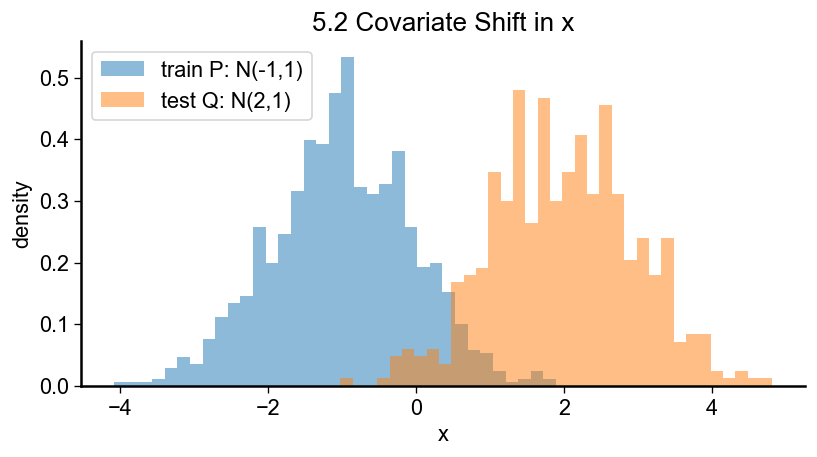

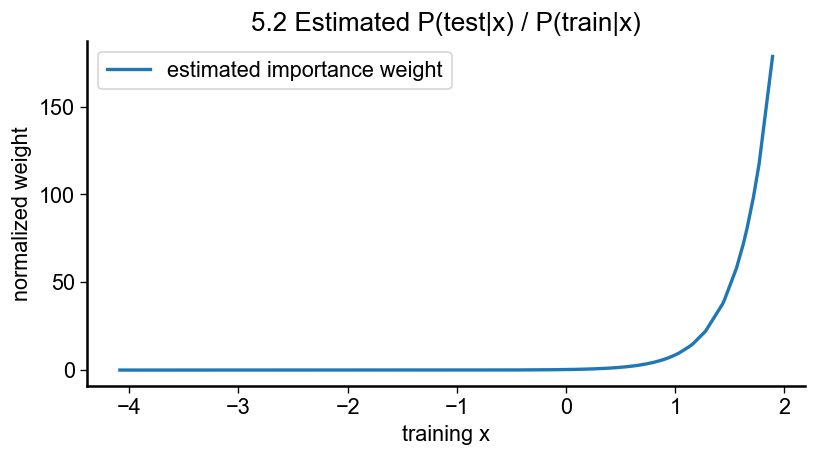

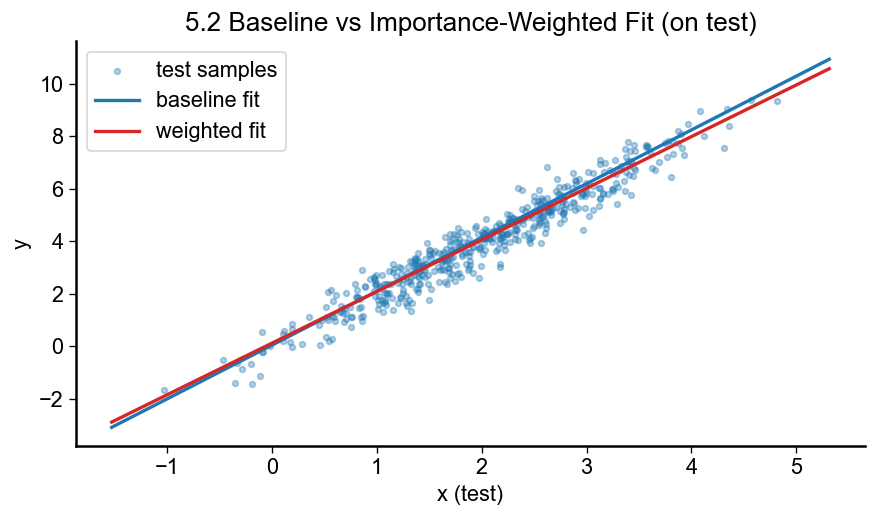

In [12]:
# 5.2 协变量偏移模拟与重要性加权校正

random.seed(270)
np.random.seed(270)
torch.manual_seed(270)

n_train, n_test = 1000, 500
noise_std = 0.5

x_train = torch.randn(n_train, 1) - 1.0
x_test = torch.randn(n_test, 1) + 2.0
y_train = 2.0 * x_train + noise_std * torch.randn(n_train, 1)
y_test = 2.0 * x_test + noise_std * torch.randn(n_test, 1)


def design_matrix(x):
    return torch.cat([torch.ones_like(x), x], dim=1)


def fit_weighted_least_squares(x, y, weights=None, ridge=1e-8):
    X = design_matrix(x)
    if weights is None:
        weights = torch.ones(x.shape[0], 1)
    sqrt_w = torch.sqrt(weights)
    Xw = X * sqrt_w
    yw = y * sqrt_w
    eye = torch.eye(X.shape[1])
    theta = torch.linalg.solve(Xw.T @ Xw + ridge * eye, Xw.T @ yw)
    return theta


def predict_linear(theta, x):
    return design_matrix(x) @ theta


def mse(y_hat, y):
    return ((y_hat - y) ** 2).mean().item()

# 基线模型
baseline_theta = fit_weighted_least_squares(x_train, y_train)
baseline_mse = mse(predict_linear(baseline_theta, x_test), y_test)

print("Training x mean/std:", float(x_train.mean()), float(x_train.std()))
print("Testing  x mean/std:", float(x_test.mean()), float(x_test.std()))
print(f"Baseline linear model: intercept={baseline_theta[0].item():.4f}, slope={baseline_theta[1].item():.4f}")
print(f"Baseline test MSE: {baseline_mse:.6f}")

# 训练逻辑回归分类器：训练集样本标记为 0，测试集样本标记为 1。
X_domain = torch.cat([x_train, x_test], dim=0)
y_domain = torch.cat([torch.zeros(n_train, 1), torch.ones(n_test, 1)], dim=0)
mu, sigma = X_domain.mean(), X_domain.std()
X_domain_std = (X_domain - mu) / sigma

w_logit = torch.zeros(1, 1, requires_grad=True)
b_logit = torch.zeros(1, requires_grad=True)
lr = 0.5
num_steps = 2000

for step in range(1, num_steps + 1):
    logits = X_domain_std @ w_logit + b_logit
    # 手动实现 binary cross entropy with logits: log(1+exp(z)) - y*z
    loss = (torch.logaddexp(torch.zeros_like(logits), logits) - y_domain * logits).mean()
    loss.backward()
    with torch.no_grad():
        w_logit -= lr * w_logit.grad
        b_logit -= lr * b_logit.grad
        w_logit.grad.zero_()
        b_logit.grad.zero_()

with torch.no_grad():
    logits_all = X_domain_std @ w_logit + b_logit
    p_test_all = torch.sigmoid(logits_all)
    domain_pred = (p_test_all >= 0.5).float()
    domain_acc = (domain_pred == y_domain).float().mean().item()

    p_test_train = torch.sigmoid(((x_train - mu) / sigma) @ w_logit + b_logit)
    p_train_train = 1.0 - p_test_train
    weights = p_test_train / (p_train_train + 1e-8)
    weights = weights / weights.mean()

print(f"Domain classifier accuracy: {domain_acc:.4f}")
print(
    "Importance weight stats | "
    f"min={weights.min().item():.4e}, median={weights.median().item():.4e}, "
    f"mean={weights.mean().item():.4e}, max={weights.max().item():.4e}"
)

weighted_theta = fit_weighted_least_squares(x_train, y_train, weights)
weighted_mse = mse(predict_linear(weighted_theta, x_test), y_test)

print(f"Weighted linear model: intercept={weighted_theta[0].item():.4f}, slope={weighted_theta[1].item():.4f}")
print(f"Weighted test MSE: {weighted_mse:.6f}")
print(f"MSE change after correction: {weighted_mse - baseline_mse:+.6f}")

plt.figure(figsize=(7, 4))
plt.hist(x_train.squeeze().numpy(), bins=35, alpha=0.5, density=True, label="train P: N(-1,1)")
plt.hist(x_test.squeeze().numpy(), bins=35, alpha=0.5, density=True, label="test Q: N(2,1)")
plt.xlabel("x")
plt.ylabel("density")
plt.title("5.2 Covariate Shift in x")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
order = torch.argsort(x_train.squeeze())
plt.plot(x_train.squeeze()[order].numpy(), weights.squeeze()[order].numpy(), label="estimated importance weight")
plt.xlabel("training x")
plt.ylabel("normalized weight")
plt.title("5.2 Estimated P(test|x) / P(train|x)")
plt.legend()
plt.tight_layout()
plt.show()

# --- extra visualization: baseline vs weighted fit on test distribution ---
with torch.no_grad():
    x_grid = torch.linspace(x_test.min() - 0.5, x_test.max() + 0.5, 200).reshape(-1, 1)
    y_base = predict_linear(baseline_theta, x_grid)
    y_w = predict_linear(weighted_theta, x_grid)

plt.figure(figsize=(7.5, 4.5))
plt.scatter(
    x_test.squeeze().numpy(),
    y_test.squeeze().numpy(),
    s=12,
    alpha=0.35,
    label="test samples",
)
plt.plot(x_grid.squeeze().numpy(), y_base.squeeze().numpy(), label="baseline fit", color="#1f77b4")
plt.plot(x_grid.squeeze().numpy(), y_w.squeeze().numpy(), label="weighted fit", color="#d62728")
plt.xlabel("x (test)")
plt.ylabel("y")
plt.title("5.2 Baseline vs Importance-Weighted Fit (on test)")
plt.legend()
plt.tight_layout()
plt.show()